# ANN Notebook: Predicting Customer Churn with a Neural Network

**Level:** beginner. **Time:** about 90 minutes. **Run it:** top to bottom, one cell at a time (Shift + Enter).

**The goal:** a telecom company wants to know *which customers are about to leave* so it can call them first. We will teach a neural network to predict that from a spreadsheet of customer details.

**What you will learn**
1. What an ANN (Artificial Neural Network) is, in plain words
2. How to clean real, messy data
3. How to turn text columns into numbers, and why we scale
4. Why we split data into train and test (and how Keras sets aside validation data for us)
5. How to build, train, and read a neural network in Keras
6. Why accuracy can lie, and what precision, recall and AUC tell you
7. How to check whether a neural network actually beats a simple model

> **How to use this notebook:** read the grey text, run the code cell under it, look at the output, and answer the "Think" questions before moving on.

## 1. What is an ANN? (the 2-minute version)

Think of an ANN as a **team of very simple decision makers arranged in rows**:

```
 Customer details  ->  [Row 1: 32 neurons]  ->  [Row 2: 16 neurons]  ->  [1 neuron]  ->  "82% likely to leave"
   (30 numbers)            (hidden layer)          (hidden layer)       (output layer)
```

- **Neuron:** takes some numbers in, multiplies each by a *weight* (how important it is), adds them up, and passes the result on.
- **Layer:** a row of neurons working side by side.
- **Hidden layer:** a middle row. It finds patterns, like "short time as a customer AND high monthly bill".
- **Output layer:** gives the final answer. Here it is one number between 0 and 1: the **probability of churn**.
- **Training:** the network guesses, checks how wrong it was, and nudges its weights to be a little less wrong. It repeats this thousands of times.

**Key idea:** the weights start random and become useful through training. Nobody types them in.

## 2. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve, precision_score, recall_score)
from sklearn.linear_model import LogisticRegression

tf.keras.utils.set_random_seed(42)   # makes results repeatable 

## 3. Load the data

This is the public **Telco Customer Churn** dataset: 7,043 real customers, one row each.
Each row says things like how long they have been a customer, their contract type, their monthly bill, and whether they **left (Churn = Yes)**.

> No internet in your lab? Download the CSV once, then use `pd.read_csv("Telco-Customer-Churn.csv")` instead.

In [3]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Explore before you model

Never train on data you have not looked at. Three quick checks:

In [4]:
# 1) Column types. Numbers should be int/float. 'object' means text.
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


**Think:** `TotalCharges` should be a number, but it says `object` (text). Something is hiding in that column. We will fix it in the next section.

In [5]:
# 2) How many customers left? (the "class balance")
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True).round(3))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


About **27%** of customers churn and 73% stay. This is called an **imbalanced** dataset.
A lazy model that always says "will stay" would be right 73% of the time and completely useless. Remember this number: it is why we will not trust accuracy alone later.

In [6]:
# 3) Does anything look different between leavers and stayers?
df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean().round(1)

,tenure,MonthlyCharges
Churn,,
No,37.6,61.3
Yes,18.0,74.4


**Think:** do customers who leave have a shorter or longer `tenure` (months with the company)? That is a pattern the network can learn.

## 5. Clean the data (the real-world part)

Three jobs:
1. Drop `customerID`. It is just a label, not useful for prediction.
2. Fix `TotalCharges`. It has blank strings (`" "`), so pandas stored it as text.
3. Turn the answer column `Churn` into 1 (left) and 0 (stayed).

In [7]:
# Proof that blanks are hiding: isna() does NOT see them
print("isna count:        ", df["TotalCharges"].isna().sum())
print("blank-string count:", (df["TotalCharges"].str.strip() == "").sum())

isna count:         0
blank-string count: 11


In [8]:
df = df.drop(columns=["customerID"])

# errors="coerce" = "if you cannot convert it, make it NaN instead of crashing"
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing after conversion:", df["TotalCharges"].isna().sum())   # now the 11 blanks are real NaN

df = df.dropna()                                  # 11 rows out of 7,043: safe to drop
df["Churn"] = (df["Churn"] == "Yes").astype(int)  # Yes -> 1 (the thing we want to catch), No -> 0

print("Rows left:", len(df))
print("Unique Churn values:", df["Churn"].unique())

Missing after conversion: 11
Rows left: 7032
Unique Churn values: [0 1]


## 6. Turn text into numbers

A neural network can only do maths, so words like `"Month-to-month"` must become numbers.
`pd.get_dummies` makes **one 0/1 column per category**:

| Contract | becomes | Contract_One year | Contract_Two year |
|---|---|---|---|
| Month-to-month | -> | 0 | 0 |
| One year | -> | 1 | 0 |
| Two year | -> | 0 | 1 |

(`drop_first=True` removes one redundant column. If both others are 0, it must be month-to-month.)

In [9]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns="Churn").astype("float32")   # features: the customer details
y = df["Churn"].values                           # target: did they leave?

feature_names = X.columns
X = X.values

print("X shape:", X.shape, " -> (customers, features)")
print("y shape:", y.shape)
print("Churn rate:", y.mean().round(3))

X shape: (7032, 30)  -> (customers, features)
y shape: (7032,)
Churn rate: 0.266


**Write down:** how many features does each customer have now? You need this number later. It is the size of the network's input.

## 7. Split the data into train and test

Imagine a student preparing for an exam:

| Set | Real-life version | Used for |
|---|---|---|
| **Train (80%)** | Textbook and practice questions | The model learns from it |
| **Test (20%)** | The real exam | Touched **once**, at the very end |

If the model ever sees the test answers while learning, the final score is fake.
`stratify=y` keeps the 27% churn rate equal in both sets.

> **What about a mock exam (validation)?** We still want to watch progress during training without touching the test set. In Section 11, Keras will automatically set aside 15% of the *training* data for that (`validation_split=0.15`). So we only need to split once here.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (5625, 30) (5625,)
Test:  (1407, 30) (1407,)


## 8. Scale the features

Look at how different the sizes are:

In [11]:
cols = list(feature_names)
pd.DataFrame(X_train, columns=cols)[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(1)

,tenure,MonthlyCharges,TotalCharges
count,5625.0,5625.0,5625.0
mean,32.6,65.0,2301.8
std,24.5,30.1,2275.6
min,1.0,18.4,18.8
25%,9.0,35.8,413.0
50%,29.0,70.6,1410.2
75%,56.0,90.1,3801.7
max,72.0,118.7,8684.8


`TotalCharges` goes up to thousands while most columns are 0 or 1. Big numbers drown out small ones and make training slow and jumpy.

**StandardScaler** fixes this: for each column, subtract the average and divide by the spread. Afterwards every column is centred near 0 with a spread of about 1.

> **Golden rule:** `fit` the scaler on **train only**, then `transform` both sets. Otherwise information from the test set leaks into training.

In [12]:
scaler = StandardScaler().fit(X_train)     # learns mean and spread from TRAIN only

X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

print("Train mean (should be ~0):", X_train.mean().round(3))
print("Train std  (should be ~1):", X_train.std().round(3))

Train mean (should be ~0): 0.0
Train std  (should be ~1): 1.0


## 9. Build the network

Each line below is one layer. Read the comments.

In [13]:
n_features = X_train.shape[1]     # use the real number, never type it by hand
print("Input size:", n_features)

model = tf.keras.Sequential([
    tf.keras.layers.Input((n_features,)),          # one customer = n_features numbers

    tf.keras.layers.Dense(32, activation="relu"),  # hidden layer 1: 32 neurons
    tf.keras.layers.Dropout(0.3),                  # during training, switch off 30% of neurons at random
                                                   # (stops the network memorising the training data)

    tf.keras.layers.Dense(16, activation="relu"),  # hidden layer 2: 16 neurons

    tf.keras.layers.Dense(1, activation="sigmoid") # OUTPUT: 1 neuron, a probability between 0 and 1
])

model.summary()

Input size: 30


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

**Reading the summary**
- `Output Shape (None, 32)`: `None` means "any number of customers at once", 32 is the number of neurons.
- `Param #` is how many numbers the layer learns. For a Dense layer: `inputs x neurons + neurons` (the last part is one *bias* per neuron).
- Check by hand: first layer = `n_features x 32 + 32`.

**Common mistakes**
- ReLU keeps positive numbers and turns negatives into 0. It lets the network learn curved, non-obvious patterns.
- **The last layer must match the question.** Yes/no question = `Dense(1, activation="sigmoid")`. If you copy `Dense(10, softmax)` from the MNIST digits notebook, you get 10 outputs per customer and everything breaks.

## 10. Compile: tell the network how to learn

| Setting | Meaning | Our choice |
|---|---|---|
| **Loss** | The "how wrong am I?" score the network tries to shrink | `binary_crossentropy` (made for yes/no answers) |
| **Optimizer** | The method used to nudge the weights | `adam` (a reliable default) |
| **Metrics** | Extra numbers shown to *us*. They do not affect learning | accuracy and AUC |

The loss must match the output layer:

| Output layer | Loss |
|---|---|
| `Dense(1, sigmoid)` (2 classes) | `binary_crossentropy` |
| `Dense(N, softmax)` (N classes, integer labels) | `sparse_categorical_crossentropy` |
| `Dense(1)` with no activation (predict a number) | `mse` |

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

## 11. Train

- **Epoch:** one full pass through all training customers.
- **Batch size 32:** the network updates its weights after every 32 customers.
- **validation_split=0.15:** Keras holds out the last 15% of the training rows as a "mock exam" and reports `val_loss` and `val_auc` after every epoch. The network never learns from these rows. (Our data is not sorted by churn, so taking the last rows is fine. On data sorted by date or class, shuffle first.)
- **EarlyStopping:** watches the *validation* loss. If it does not improve for 5 epochs, training stops and the best weights are restored. This prevents over-training.

In [15]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7329 - auc: 0.7290 - loss: 0.5314 - val_accuracy: 0.7938 - val_auc: 0.8156 - val_loss: 0.4420
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7818 - auc: 0.8122 - loss: 0.4536 - val_accuracy: 0.7974 - val_auc: 0.8337 - val_loss: 0.4241
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7913 - auc: 0.8185 - loss: 0.4463 - val_accuracy: 0.7986 - val_auc: 0.8418 - val_loss: 0.4154
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7919 - auc: 0.8295 - loss: 0.4353 - val_accuracy: 0.8021 - val_auc: 0.8467 - val_loss: 0.4107
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7984 - auc: 0.8336 - loss: 0.4314 - val_accuracy: 0.8081 - val_auc: 0.8502 - val_loss: 0.4066
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8019 - auc: 0.8368 - loss: 0.4283 - val_accuracy: 0.8081 - val_auc: 0.8507 - val_loss: 0.4062
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 

## 12. Read the learning curves

These plots show whether training went well.

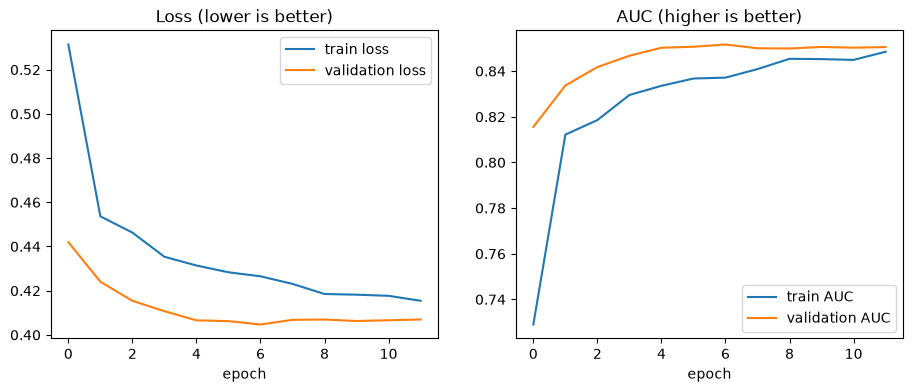

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(history.history["loss"], label="train loss")
ax[0].plot(history.history["val_loss"], label="validation loss")
ax[0].set_title("Loss (lower is better)"); ax[0].set_xlabel("epoch"); ax[0].legend()

ax[1].plot(history.history["auc"], label="train AUC")
ax[1].plot(history.history["val_auc"], label="validation AUC")
ax[1].set_title("AUC (higher is better)"); ax[1].set_xlabel("epoch"); ax[1].legend()

plt.show()

**How to read them**
- Both loss lines going **down** together = the network is learning.
- Train loss keeps falling but validation loss turns **up** = **overfitting** (memorising instead of learning). EarlyStopping exists to stop at the best point.
- Lines that stay flat and high = it is not learning (check scaling, output layer, loss).

## 13. Evaluate on the test set (the real exam)

`model.predict` gives a probability for each customer. We turn it into a yes/no with a **threshold** (0.5 means "flag as churn if probability is above 50%").

In [25]:
raw = model.predict(X_test, verbose=0)
print("Raw predict shape:", raw.shape)         # (customers, 1)

probs = raw.ravel()                            # flatten (customers, 1) into (customers,)
assert probs.shape == y_test.shape, "Shapes differ! Is the last layer Dense(1)?"
print("probs shape:", probs.shape, " y_test shape:", y_test.shape)
print("First 5 probabilities:", probs[:5].round(3))

Raw predict shape: (1407, 1)
probs shape: (1407,)  y_test shape: (1407,)
First 5 probabilities: [0.016 0.611 0.01  0.216 0.11 ]


In [18]:
pred = (probs > 0.5).astype(int)
print(classification_report(y_test, pred, target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407



**Reading the report (look at the "Churned" row)**

| Term | Plain meaning | Question it answers |
|---|---|---|
| **Precision** | Of those I flagged as leaving, how many really left? | "How many of my calls were wasted?" |
| **Recall** | Of those who really left, how many did I catch? | "How many leavers did I miss?" |
| **F1** | One number balancing precision and recall | "Overall, how good is it on churners?" |
| **Support** | How many real customers are in that class | |

Compare **accuracy** with the lazy baseline (about 73%). The gap is small, which is why recall on the churn class matters more.

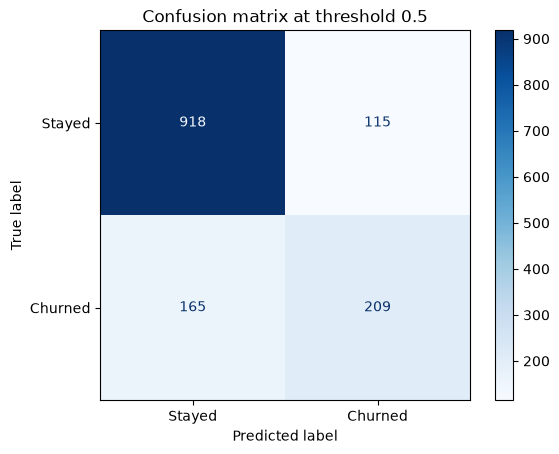

Correctly caught churners (TP): 209
Missed churners          (FN): 165
False alarms             (FP): 115
Correctly cleared        (TN): 918


In [19]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(cmap="Blues")
plt.title("Confusion matrix at threshold 0.5")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Correctly caught churners (TP): {tp}")
print(f"Missed churners          (FN): {fn}")
print(f"False alarms             (FP): {fp}")
print(f"Correctly cleared        (TN): {tn}")

## 14. ROC curve and AUC

The ROC curve shows what happens as we slide the threshold from strict to lenient.
- **Y axis:** share of real churners caught (recall). **High is good.**
- **X axis:** share of loyal customers wrongly flagged. **Low is good.**
- Best corner: **top-left**. The dashed diagonal is a coin flip.
- **AUC** = area under the curve. 0.5 = coin flip, 0.8 to 0.9 = good, 1.0 = perfect.

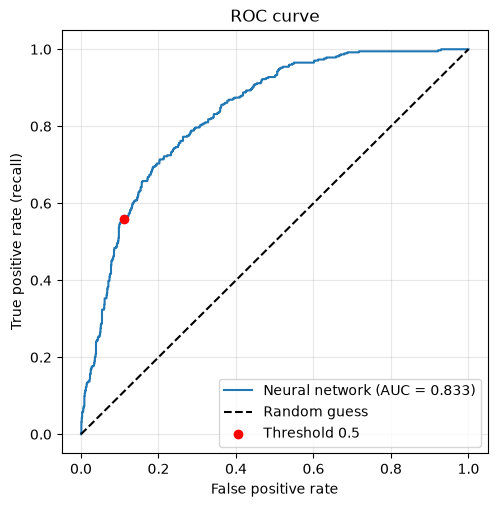

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(5.5, 5.5))
plt.plot(fpr, tpr, label=f"Neural network (AUC = {roc_auc_score(y_test, probs):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.scatter(fp / (fp + tn), tp / (tp + fn), color="red", zorder=5, label="Threshold 0.5")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate (recall)")
plt.title("ROC curve"); plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

## 15. Is the neural network actually better than a simple model?

Always compare against a **baseline**. Logistic regression is basically a neural network with no hidden layers.

Logistic regression AUC: 0.836
Neural network AUC:      0.833


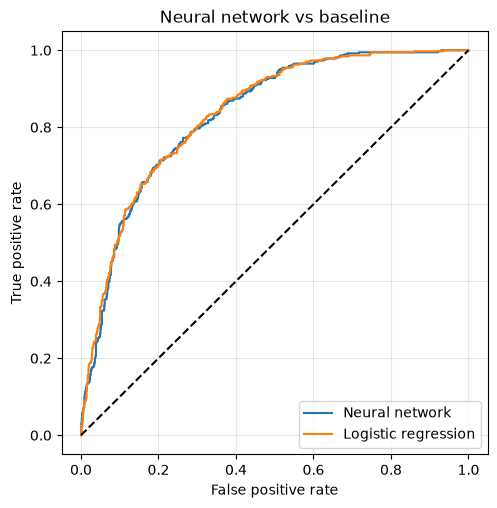

In [21]:
lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)[:, 1]      # column 1 = probability of churn

print(f"Logistic regression AUC: {roc_auc_score(y_test, lr_probs):.3f}")
print(f"Neural network AUC:      {roc_auc_score(y_test, probs):.3f}")

fpr2, tpr2, _ = roc_curve(y_test, lr_probs)
plt.figure(figsize=(5.5, 5.5))
plt.plot(fpr, tpr, label="Neural network")
plt.plot(fpr2, tpr2, label="Logistic regression")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Neural network vs baseline"); plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

**Honest conclusion:** on a small table like this, the two usually score almost the same (about 0.83 to 0.84). Neural networks shine on images, text and audio. On small spreadsheets, a simple model is often just as good, faster, and easier to explain. Knowing this is a real skill.

## 16. Choose a threshold using business cost

0.5 is not magic. If missing a churner is expensive and a retention call is cheap, lower the threshold.

In [22]:
rows = []
for t in [0.6, 0.5, 0.4, 0.3, 0.2]:
    p = (probs > t).astype(int)
    rows.append({"threshold": t,
                 "recall (churners caught)": round(recall_score(y_test, p), 2),
                 "precision (calls that were right)": round(precision_score(y_test, p, zero_division=0), 2),
                 "customers flagged": int(p.sum())})
pd.DataFrame(rows)

,threshold,recall (churners caught),precision (calls that were right),customers flagged
0,0.6,0.40,0.66,226
1,0.5,0.56,0.65,324
2,0.4,0.69,0.58,450
3,0.3,0.76,0.52,545
4,0.2,0.87,0.45,731


**Think:** as the threshold drops, recall goes up and precision goes down. If each retention call costs 1 unit and each lost customer costs 20, which threshold would you pick?

## 17. Make it useful: who do we call first?

In [23]:
top = np.argsort(-probs)[:10]          # indices of the 10 highest churn probabilities
call_list = pd.DataFrame({"test_row": top,
                          "churn_probability": probs[top].round(2),
                          "actually_churned": y_test[top]})
call_list

,test_row,churn_probability,actually_churned
0,984,0.88,1
1,211,0.87,0
2,439,0.86,1
3,1080,0.85,1
4,1149,0.85,1
5,1376,0.84,1
6,902,0.84,1
7,1338,0.82,1
8,346,0.82,1
9,591,0.82,1


## 18. Exercises

1. **Change the network.** Try `Dense(64)` then `Dense(32)`, or remove Dropout. Does validation AUC change? Run each version 3 times with different seeds before claiming a difference. Small differences are usually noise.
2. **Break it on purpose.** Skip the scaling step and train again. What happens to the loss curves?
3. **Class weights.** Add `class_weight={0: 1, 1: 2.5}` to `model.fit`. What happens to churn recall and precision?
4. **Another dataset.** Repeat the pipeline on a heart-disease or diabetes CSV. What stays the same? What changes?
5. **Regression.** Predict `MonthlyCharges` instead of churn. Which three things must change? (Hint: output layer, loss, metrics.)
6. **Save the model**: Save the model in preparation for deployment

## Cheat sheet

| Concept | One-line summary |
|---|---|
| Neuron | Weighted sum of inputs, then an activation |
| ReLU | Keeps positives, zeroes negatives (hidden layers) |
| Sigmoid | Squashes to 0..1 (yes/no output) |
| Softmax | Probabilities across 3+ classes that sum to 1 |
| Dropout | Randomly switches off neurons during training only |
| Epoch | One pass through the training data |
| Overfitting | Great on train, worse on validation |
| Precision / Recall | Calls that were right / leavers that were caught |
| AUC | How well the model ranks leavers above stayers |